# Validation of ACA level-0 cheta telemetry ingest PR #291

This notebook compares the data values in the cheta ACA level-0 archive to the same
from `mica.archive.aca_l0`. It also demonstrates that units work and that the image
telemetry CCD temperature matches (to within expected) the same from OBC telemetry.

In [1]:
import os
import sys
from pathlib import Path

SKA = Path(os.environ["SKA"])
parent_dir = os.path.abspath("..")
os.environ["ENG_ARCHIVE"] = f"{parent_dir}:{SKA}/data/eng_archive"

sys.path.insert(0, parent_dir)
# import pickle

import astropy.table as apt
import matplotlib.pyplot as plt
import matplotlib.style
import numpy as np
from cxotime import CxoTime
from mica.archive import aca_l0
from ska_matplotlib import plot_cxctime

import cheta
from cheta import fetch, fetch_eng, fetch_sci

matplotlib.style.use("bmh")
%matplotlib inline

fetch: using ENG_ARCHIVE=/Users/aldcroft/git/cheta:/Users/aldcroft/ska/data/eng_archive for archive path


In [2]:
# Configure matplotlib for smaller file sizes
plt.rcParams["figure.dpi"] = 72  # Lower DPI
plt.rcParams["savefig.dpi"] = 72  # Lower DPI for saved figures
%config InlineBackend.figure_format = 'jpg'                    # Use JPEG

In [3]:
cheta.__version__

'4.68.1.dev13+g6c794d4c1'

In [4]:
start, stop = "2026:150:00:00:00", "2026:160:00:00:00"

In [5]:
dat_micas = [
    apt.Table(aca_l0.get_slot_data(start, stop, slot=slot, imgsize=[8]))
    for slot in range(8)
]

#### Validate image telemetry for 8 slots over a 10 day span

This shows that the cheta archive data match the mica L0 telemetry images and times
exactly.

In [6]:
for slot in range(8):
    print(f"aca{slot}_imgtlm", end="")
    aca_imgtlm = fetch_sci.Msid(f"aca{slot}_imgtlm", start, stop)
    aca_imgscale = fetch_sci.Msid(f"aca{slot}_imgscale", start, stop)
    dat_mica = dat_micas[slot]
    dat_mica["IMGRAW"] = dat_mica["IMGRAW"].reshape(-1, 8, 8)
    assert len(dat_mica) == len(aca_imgtlm)  # noqa: S101
    assert np.all(CxoTime(dat_mica["TIME"]) == CxoTime(aca_imgtlm.times))  # noqa: S101
    imgraw = aca_imgtlm.vals * (aca_imgscale.vals[:, None, None] / 32.0) - 50.0
    assert np.all(imgraw == dat_mica["IMGRAW"])  # noqa: S101
    assert imgraw.shape == dat_mica["IMGRAW"].shape  # noqa: S101
    print(f" ✅  {len(dat_mica)} rows, {imgraw.shape} images")

aca0_imgtlm ✅  209733 rows, (209733, 8, 8) images
aca1_imgtlm ✅  209740 rows, (209740, 8, 8) images
aca2_imgtlm ✅  209720 rows, (209720, 8, 8) images
aca3_imgtlm ✅  209792 rows, (209792, 8, 8) images
aca4_imgtlm ✅  209779 rows, (209779, 8, 8) images
aca5_imgtlm ✅  209796 rows, (209796, 8, 8) images
aca6_imgtlm ✅  209810 rows, (209810, 8, 8) images
aca7_imgtlm ✅  209632 rows, (209632, 8, 8) images


#### Validate CCD temperature and units

There is a known offset between temperatures in image telemetry vs. OBC telemetry.

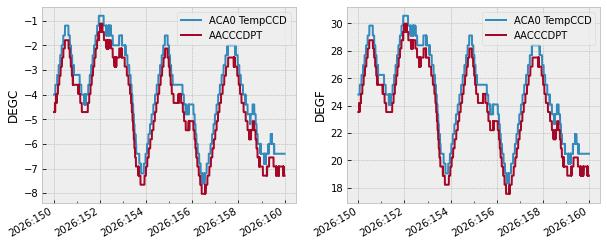

In [7]:
fig, (ax0, ax1) = plt.subplots(ncols=2, nrows=1, figsize=(10, 4))
aca0_tempccd = fetch_sci.Msid("aca0_tempccd", start, stop)
aacccdpt = fetch_sci.Msid("aacccdpt", start, stop)
plot_cxctime(aca0_tempccd.times, aca0_tempccd.vals, ax=ax0, label="ACA0 TempCCD")
plot_cxctime(aacccdpt.times, aacccdpt.vals, ax=ax0, label="AACCCDPT")
ax0.set_ylabel("DEGC")
ax0.legend()
aca0_tempccd = fetch_eng.Msid("aca0_tempccd", start, stop)
aacccdpt = fetch_eng.Msid("aacccdpt", start, stop)
plot_cxctime(aca0_tempccd.times, aca0_tempccd.vals, ax=ax1, label="ACA0 TempCCD")
plot_cxctime(aacccdpt.times, aacccdpt.vals, ax=ax1, label="AACCCDPT")
ax1.set_ylabel("DEGF")
ax1.legend();

#### Validate all other columns: cheta matches mica L0

In [8]:
import re

skip = set(["END_INTEG_TIME", "TIME", "QUALITY", "IMGRAW", "IMGSIZE", "FILENAME"])

for slot in range(8):
    print(slot, end="")
    for colname in dat_mica.colnames:
        if colname in skip:
            continue
        msid = f"aca{slot}_{colname.lower()}"
        if re.match(r"IMG(FID|NUM|FUNC)[1234]$", colname):
            msid = msid[:-1]
        dat_cheta = fetch.Msid(msid, start, stop)
        dat_mica = dat_micas[slot]
        assert len(dat_cheta) == len(dat_mica[colname])  # noqa: S101
        assert np.all(dat_mica["TIME"] == dat_cheta.times)  # noqa: S101
        assert np.all(dat_mica[colname] == dat_cheta.vals)  # noqa: S101
    print(" ✅")

0 ✅
1 ✅
2 ✅
3 ✅
4 ✅
5 ✅
6 ✅
7 ✅
